In [1]:
import os
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from scipy.signal import welch

No_aces

In [2]:
no_aces = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed"
print(os.path.exists(no_aces))

True


In [3]:
files = glob.glob(os.path.join(no_aces, "*AveOverTrials.txt"))

fs = 500  

In [4]:
all_subject_psd = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))

Subjects: 47


In [5]:
all_subject_psd = np.vstack(all_subject_psd)

group_psd = np.mean(all_subject_psd, axis=0)

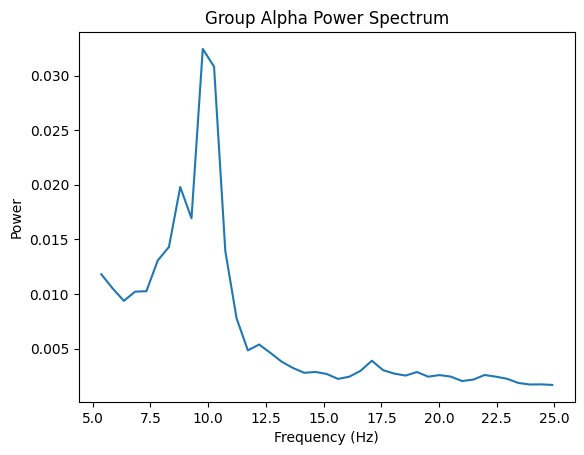

In [7]:
import matplotlib.pyplot as plt

alpha_mask = (freqs >= 5) & (freqs <= 25)

plt.plot(freqs[alpha_mask], group_psd[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

## Better Version No_aces

In [8]:
eps = 1e-12
log_psd = np.log10(group_psd + eps)

In [9]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm = log_psd - baseline

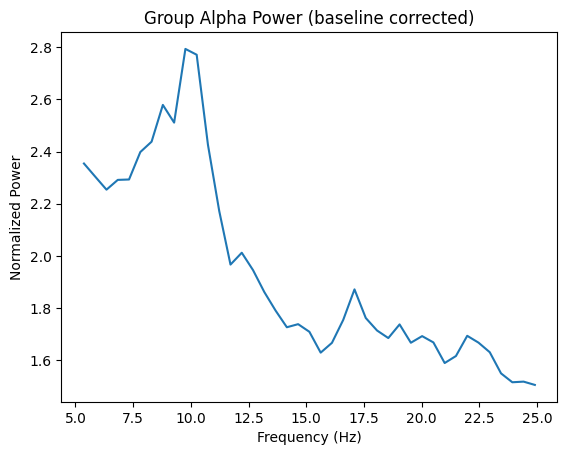

In [10]:
alpha_mask = (freqs >= 5) & (freqs <= 25)
plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

### Z-Score

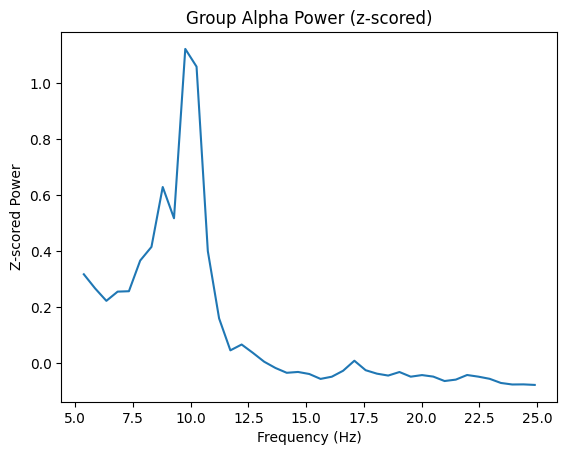

In [11]:
psd_mean = np.mean(group_psd)
psd_std = np.std(group_psd)
psd_z = (group_psd - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# 2nd Better Version No_ACEs

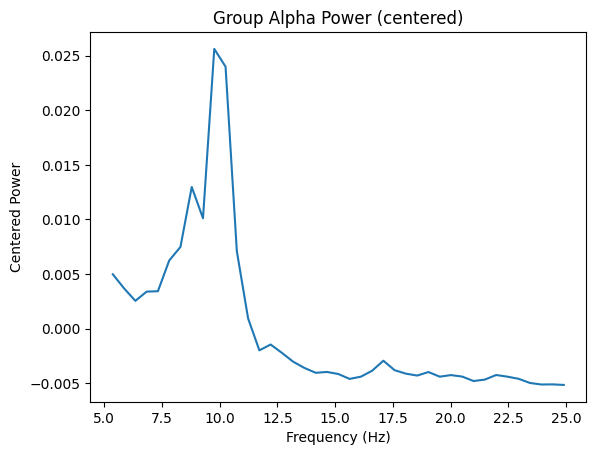

In [12]:
alpha_mask = (freqs >= 5) & (freqs <= 25)

alpha_power = group_psd[alpha_mask]
alpha_power_centered = alpha_power - np.mean(alpha_power)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

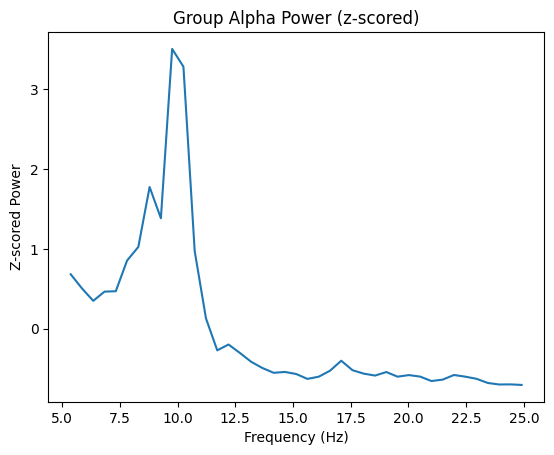

In [13]:
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

plt.plot(freqs[alpha_mask], alpha_power_z)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# ACES

In [14]:
aces = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed\\EC_ACES"
print(os.path.exists(aces))

True


In [15]:
files = glob.glob(os.path.join(aces, "*AveOverTrials.txt"))

fs = 500   # ⚠️ CHANGE to your sampling rate

In [16]:
all_subject_psd = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))

Subjects: 151


In [17]:
all_subject_psd = np.vstack(all_subject_psd)

group_psd_aces = np.mean(all_subject_psd, axis=0)

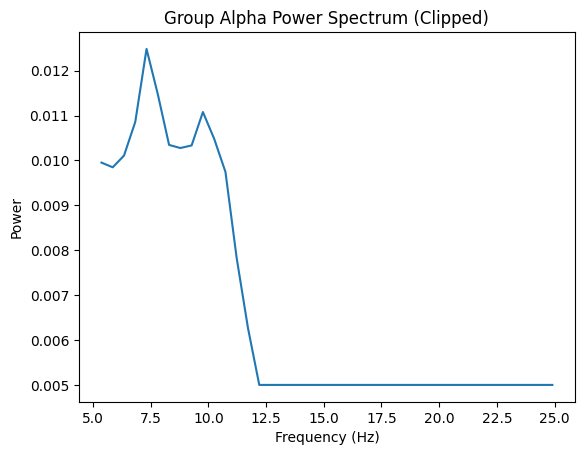

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Mask for alpha band
alpha_mask = (freqs >= 5) & (freqs <= 25)

# Clip power values to desired range
clipped_psd = np.clip(group_psd_aces[alpha_mask], 0.005, 0.030)

# Plot
plt.plot(freqs[alpha_mask], clipped_psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum (Clipped)")
plt.show()

# Better Version ACES

In [19]:
eps = 1e-12
log_psd = np.log10(group_psd_aces + eps)

In [20]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm = log_psd - baseline

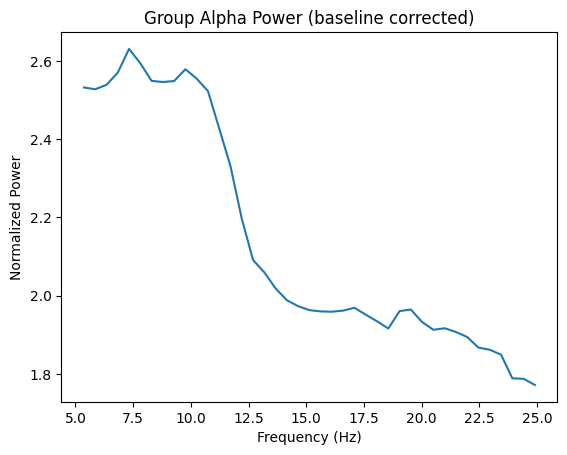

In [21]:
alpha_mask = (freqs >= 5) & (freqs <= 25)
plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

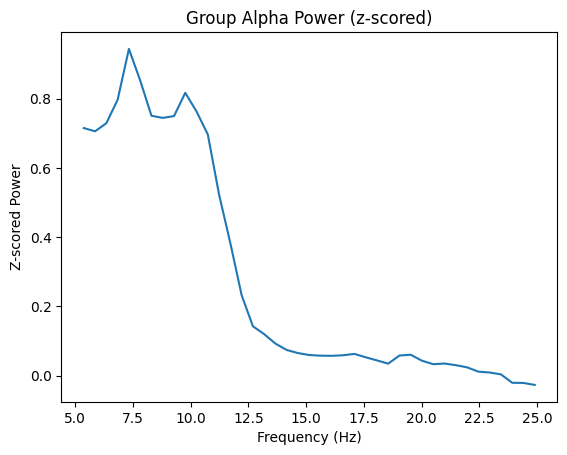

In [22]:
psd_mean = np.mean(group_psd_aces)
psd_std = np.std(group_psd_aces)
psd_z = (group_psd_aces - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

### 2nd Version

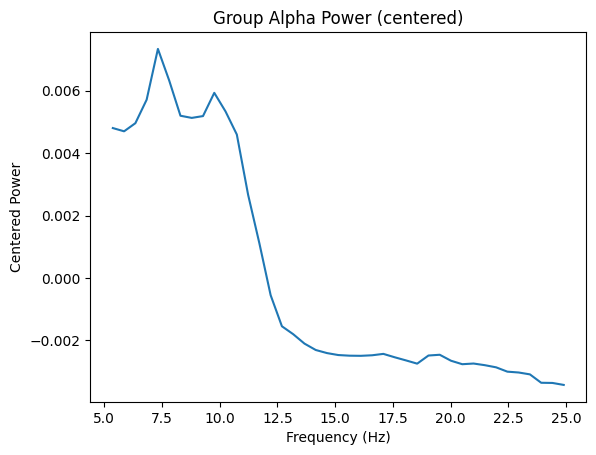

In [23]:
alpha_mask = (freqs >= 5) & (freqs <= 25)

alpha_power_aces = group_psd_aces[alpha_mask]
alpha_power_centered_aces = alpha_power_aces - np.mean(alpha_power_aces)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_aces)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

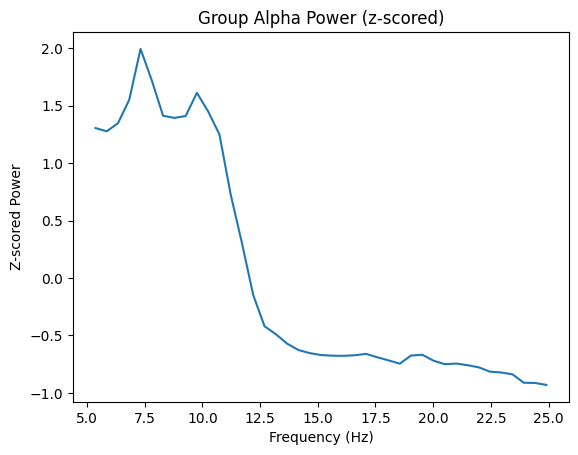

In [24]:
alpha_power_ace = group_psd_aces[alpha_mask]
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

plt.plot(freqs[alpha_mask], alpha_power_z_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# Together Eyes Closed

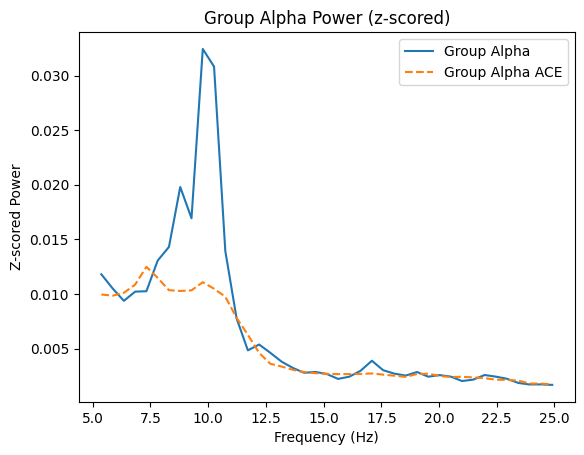

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Alpha band mask
alpha_mask = (freqs >= 5) & (freqs <= 25)

# First line
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

# Second line (ACE)
alpha_power_ace = group_psd_aces[alpha_mask]  # replace this with actual ACE data if different
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

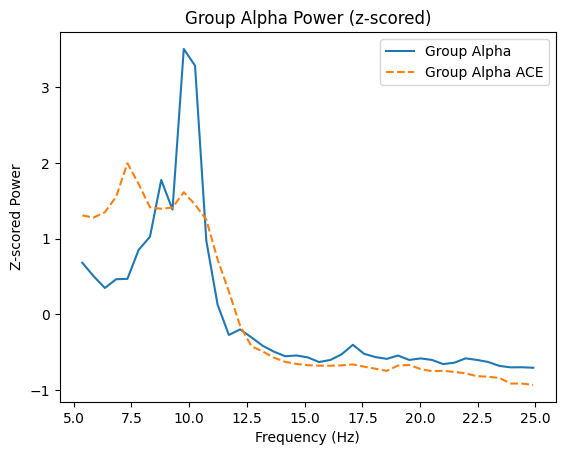

In [26]:
import matplotlib.pyplot as plt
import numpy as np



# First line
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

# Second line (ACE)
alpha_power_ace = group_psd_aces[alpha_mask]  # use the actual ACE data here
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()